Imports

In [19]:
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

Create Filtered CSV For EDA

In [25]:
# Notebook-friendly paths (no __file__ in Jupyter)
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
TWEETS_PATH = DATA_DIR / 'tweets.txt'
EMOJI_PATH = DATA_DIR / 'emoji.txt'
OUT_CSV = DATA_DIR / 'filtered_tweets.csv'

# Remove all mentions
MENTION_RE = re.compile(r'@\w+')
URL_RE = re.compile(r'https?://\S+|www\.\S+', re.I)
# Remote Retweet syntax
RT_PREFIX_RE = re.compile(r'^\s*rt\s*:\s*', re.I)
SPACE_RE = re.compile(r'\s+')


def clean_tweet(text: str) -> str:
    text = URL_RE.sub('', text)
    text = MENTION_RE.sub('', text)
    text = SPACE_RE.sub(' ', text).strip()
    text = RT_PREFIX_RE.sub('', text)
    return text.strip()


rows = []
with open(TWEETS_PATH, encoding='utf-8', errors='replace') as tf, open(
    EMOJI_PATH, encoding='utf-8', errors='replace'
) as ef:
    for line_no, (tweet_line, emoji_line) in enumerate(zip(tf, ef), start=1):
        raw = tweet_line.rstrip('\n\r')
        emoji_label = emoji_line.strip()
        mention_count = raw.count('@')
        is_retweet = raw.lstrip().lower().startswith('rt @')
        tweet_body = clean_tweet(raw)
        char_count = len(tweet_body)
        has_question_mark = '?' in tweet_body
        has_exclamation_mark = '!' in tweet_body
        rows.append(
            {
                'LINE_NUM': line_no,
                'TWEET': tweet_body,
                'EMOJI': emoji_label,
                'CHAR_COUNT': char_count,
                'MENTION_COUNT': mention_count,
                'HAS_QUESTION_MARK': has_question_mark,
                'HAS_EXCLAMATION_MARK': has_exclamation_mark,
                'IS_RETWEET': is_retweet,
            }
        )

df = pd.DataFrame(rows)

# Remove dupe tweets
df = df[df['TWEET'].duplicated(keep=False)]
df.to_csv(OUT_CSV, index=False)

print(f'Wrote {len(df)} rows to {OUT_CSV}')

Wrote 100103 rows to c:\Users\avina\Emojithon\data\filtered_tweets.csv


In [26]:
TRAIN_CSV = DATA_DIR / 'filtered_tweets.csv'

df = pd.read_csv(TRAIN_CSV)



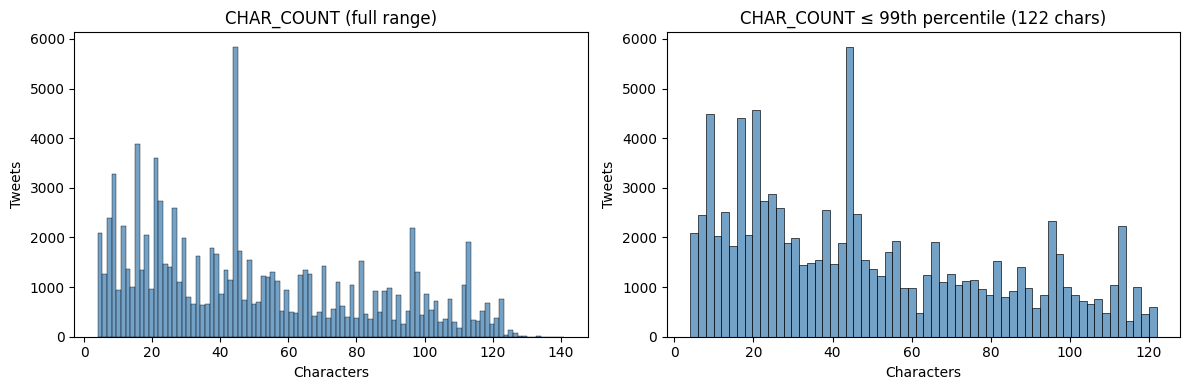

count    100103.000000
mean         49.538126
std          33.228376
min           4.000000
25%          21.000000
50%          44.000000
75%          74.000000
max         141.000000
Name: CHAR_COUNT, dtype: float64


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['CHAR_COUNT'], bins=100, kde=False, ax=axes[0], color='steelblue')
axes[0].set_title('CHAR_COUNT (full range)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Tweets')

p99 = float(df['CHAR_COUNT'].quantile(0.99))
subset = df.loc[df['CHAR_COUNT'] <= p99, 'CHAR_COUNT']
sns.histplot(subset, bins=60, kde=False, ax=axes[1], color='steelblue')
axes[1].set_title(f'CHAR_COUNT ≤ 99th percentile ({p99:.0f} chars)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Tweets')

plt.tight_layout()
plt.show()

print(df['CHAR_COUNT'].describe())

In [ ]:
df['CHAR_COUNT'].value_counts()

np.float64(49.53812573049759)